In [1]:
# ==========================================================
# Imports
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss

from xgboost import XGBClassifier

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
# ==========================================================
# Load Feature Dataset
# ==========================================================


DATA = "/kaggle/input/notebooks/shri7ul/03-feature-engineering-ipynb/master_feature_engineered.parquet"

master = pd.read_parquet(DATA)

master = pd.read_parquet(DATA)

TARGET = "is_correct"

DROP_COLUMNS = [

    "response_id",
    "session_id",

    "learning_objective",
    "learning_objective_id",

    "transcript",
    "student_text",
    "tutor_text",
    "background_text",

    TARGET,
]

X = master.drop(columns=DROP_COLUMNS)

y = master[TARGET].astype(int)

for col in X.select_dtypes(include="object").columns:
    X[col] = X[col].astype("category").cat.codes

print(X.shape)

(35072, 113)


In [3]:
BEST_PARAMS = {

    "objective":"binary:logistic",
    "eval_metric":"logloss",
    "tree_method":"hist",
    "random_state":42,

    "n_estimators":4000,

    "learning_rate":0.013793,
    "max_depth":8,
    "min_child_weight":2,

    "subsample":0.882115,
    "colsample_bytree":0.712985,

    "gamma":1.632022,

    "reg_alpha":0.461505,
    "reg_lambda":2.521299,

}

In [4]:
model = XGBClassifier(**BEST_PARAMS)

model.fit(
    X,
    y,
    verbose=False,
)

importance = pd.DataFrame({

    "feature":X.columns,

    "importance":model.feature_importances_,

})

importance = importance.sort_values(

    "importance",

    ascending=False,

)

importance.head(20)

,feature,importance
8,obj_has_decimal,0.035956
23,obj_has_percentage,0.029055
9,obj_has_money,0.028220
5,objective_word_count,0.018288
4,objective_char_count,0.018281
3,objective_frequency_percentile,0.017503
25,obj_has_area,0.017030
16,obj_has_division,0.016892
6,objective_avg_word_length,0.016863
0,objective_frequency,0.016568


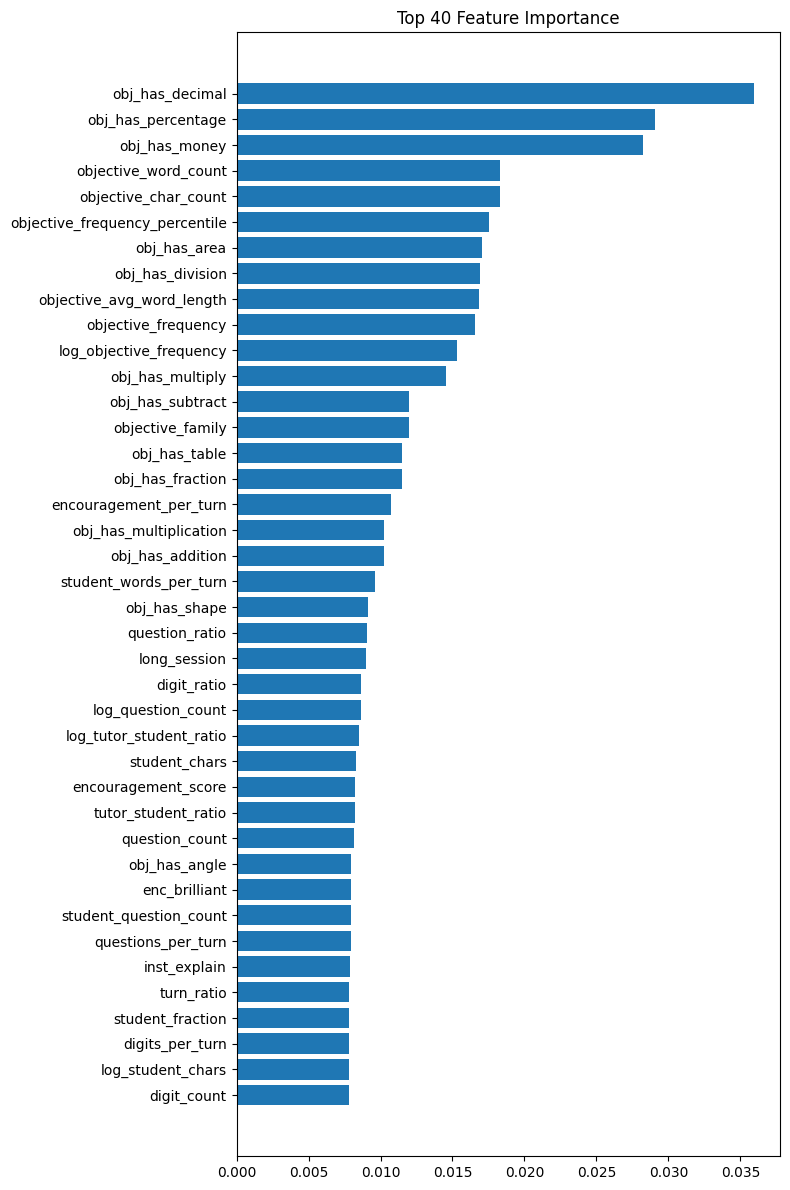

In [5]:
plt.figure(figsize=(8,12))

plt.barh(

    importance.head(40)["feature"][::-1],

    importance.head(40)["importance"][::-1],

)

plt.title("Top 40 Feature Importance")

plt.tight_layout()

plt.show()

In [6]:
importance.tail(30)

,feature,importance
67,uppercase_count,0.007322
30,tutor_chars,0.007302
107,log_instruction_score,0.007295
82,inst_think,0.007294
101,instruction_per_turn,0.007273
71,enc_excellent,0.007243
73,enc_perfect,0.007241
62,unclear_count,0.007233
87,inst_tell,0.007222
86,inst_look,0.007214


In [7]:
BASELINE = 0.542709

print("Baseline LogLoss :", BASELINE)

Baseline LogLoss : 0.542709


In [8]:
REMOVE = [

    "obj_has_probability",
    "obj_has_length",
    "stu_dont_know",
    "obj_has_volume",
    "many_questions",

]

X_fs = X.drop(columns=REMOVE)

print("Original :", X.shape)
print("Selected :", X_fs.shape)

Original : (35072, 113)
Selected : (35072, 108)


In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from xgboost import XGBClassifier

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

oof = np.zeros(len(X_fs))
scores = []

for fold, (tr, va) in enumerate(kf.split(X_fs, y), 1):

    X_train = X_fs.iloc[tr]
    y_train = y.iloc[tr]

    X_valid = X_fs.iloc[va]
    y_valid = y.iloc[va]

    model = XGBClassifier(

        objective="binary:logistic",

        eval_metric="logloss",

        tree_method="hist",

        random_state=42,

        n_estimators=6000,

        learning_rate=0.013793,

        max_depth=8,

        min_child_weight=2,

        subsample=0.882115,

        colsample_bytree=0.712985,

        gamma=1.632022,

        reg_alpha=0.461505,

        reg_lambda=2.521299,

        early_stopping_rounds=300,
    )

    model.fit(

        X_train,
        y_train,

        eval_set=[(X_valid, y_valid)],

        verbose=False,
    )

    pred = model.predict_proba(X_valid)[:,1]

    oof[va] = pred

    loss = log_loss(y_valid, pred)

    scores.append(loss)

    print(f"Fold {fold} : {loss:.6f}")

overall = log_loss(y, oof)

print()
print("="*60)
print("Mean :", np.mean(scores))
print("OOF  :", overall)
print("="*60)

Fold 1 : 0.538153
Fold 2 : 0.546708
Fold 3 : 0.544203
Fold 4 : 0.544256
Fold 5 : 0.544376

Mean : 0.54353903933945
OOF  : 0.5435389761022443


In [10]:
print("Baseline :", BASELINE)
print("Current  :", overall)

print()

if overall < BASELINE:
    print("✅ KEEP Feature Selection")
else:
    print("❌ REVERT")

Baseline : 0.542709
Current  : 0.5435389761022443

❌ REVERT
